In [1]:
using Revise
using SSMCMain.ModifiedMiCRM.MinimalModelV2

In [2]:
using ProgressMeter
using ColorSchemes
using JLD2


In [3]:
includet("../../scripts/figures_util.jl")

using GLMakie
using CairoMakie
CairoMakie.activate!()

# Finding betas for a set number of peaks

In [301]:
using Optim

function find_beta_for_Lmax(Lmax, l, p;
    betamax=1e6,
    tol1=1e5 * eps(),
    tol2=1e-5,
)
    beta_min = MinimalModelV2.fr2_beta_lb(l)
    beta_max = min(MinimalModelV2.fr2_beta_ub(l, p), betamax)
    s = optimize(beta_min, beta_max) do beta
        km2 = MinimalModelV2.fr2_km2(beta, l, p, 1.)
        (MinimalModelV2.ksquared_to_L(km2) - Lmax)^2
    end
    if abs(s.minimum) > tol1
        if abs(s.minimizer - beta_min) < tol2
            @error "Hitting the maximum L_max, not a real optimum"
        else
            throw(ErrorException("Optimizer did not work"))
        end
    end
    # @show s.minimum s.minimizer;
    s.minimizer
end

find_beta_for_Lmax (generic function with 1 method)

In [303]:
find_beta_for_Lmax(0.1, 1., 1e-3)

4.410354021384252

In [309]:
L = 5

Ns = [10, 15, 20]
lis = [1.]
ps = [1.]

Klips = []
for p in ps
    for li in lis
        for N in Ns
            Lmax = L / N
            beta = find_beta_for_Lmax(Lmax, li, p)
            push!(Klips, (beta, li, p))
        end
    end
end
Klips

3-element Vector{Any}:
 (10.782736830354969, 1.0, 1.0)
 (15.176070792347483, 1.0, 1.0)
 (19.59437173444063, 1.0, 1.0)

# Lengthscales theory plot v2

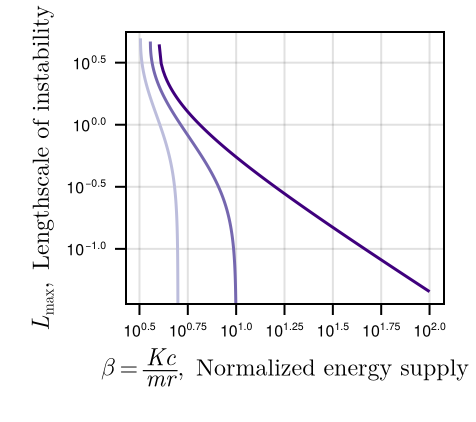

In [203]:
ls = [1., 0.9, 0.8]
ps = [1.]

lmin, lmax = extrema(ls)
ldelta = lmax - lmin
pmin, pmax = extrema(ps)
pdelta = pmax - pmin

# cc = cgrad(ColorSchemes.dense[50:end])
cc = cgrad(ColorSchemes.Purples[4:end])
# cc = cgrad(ColorSchemes.Reds[4:end])

fig = Figure(;
    # size=(double_col_width * 1.6, 1.4 * double_col_width / golden_ratio)
    size=(double_col_width * 0.35, (double_col_width / golden_ratio) * 0.5),
)
ax = Axis(fig[1,1];
    yscale=log10,
    xscale=log10,
    xlabel=L"\beta=\frac{Kc}{mr},\enspace\text{Normalized energy supply}",
    # xlabel=L"K,\enspace\text{Resource supply rate}",
    ylabel=L"L_\text{max},\enspace\text{Lengthscale of instability}",
    xlabelsize=8fontsize_ltex_pt,
    ylabelsize=8fontsize_ltex_pt,
    xticklabelsize=6fontsize_pt,
    yticklabelsize=6fontsize_pt,
)

for p in ps
    for l in ls
        betas = MinimalModelV2.fr2_instab_beta_range(l, p, 1000; betamax=100.)
        km2s = MinimalModelV2.fr2_km2.(betas, l, p, 1.)
        Lms = MinimalModelV2.ksquared_to_L.(km2s)
        
        lines!(ax, betas, Lms;
            label=(@sprintf "l=%.2f, p=%.2f" l p),
            linestyle=p == 1 ? :solid : :dash,
            color=get(cc, (l - lmin) / ldelta)
        )
    end
end

#= lmarkers = [MarkerElement(; marker=:rect, markersize=10, color=get(cc, (l - lmin) / ldelta)) for l in ls]
pmarkers = [LineElement(; linestyle=(p == 1. ? :solid : :dash)) for p in ps]
llabels = [(@sprintf "%.3g" l) for l in ls]
plabels = [(@sprintf "%.3g" p) for p in ps]

axislegend(ax,
    [lmarkers, pmarkers],
    [llabels, plabels],
    # [L"l", L"p=\frac{D_R}{D_I}"];
    [L"\text{Leakage},\enspace l", L"p=\frac{D_R}{D_I}"];
    nbanks=3,
    # orientation=:horizontal,
    titleposition=:left,
    titlesize=8fontsize_ltex_pt,
    padding=(6., 6., 2., 2.),
    rowgap=0.,
    colgap=0.,
    patchsize=(18., 15.),
    groupgap=0.,
    patchlabelgap=2.,
    labelsize=8fontsize_pt,
) =#

oaoa = (0.5:0.25:2.)
ax.xticks = (10. .^ oaoa, [rich("10", superscript(string(e))) for e in oaoa])

# Makie.save("../../figures/fig3_mm_what/lengths2.pdf", fig)

fig

In [5]:
b0 = 5
L1 = MinimalModelV2.ksquared_to_L(MinimalModelV2.fr2_km2(10^(b0), 1., 1., 1.))
L2 = MinimalModelV2.ksquared_to_L(MinimalModelV2.fr2_km2(10^(b0+1), 1., 1., 1.))
log10(L2) - log10(L1)

-1.0000068402577265